In [1]:
# 1. Create Project Directory Structure (local-inside Colab)
import os

base_dir = "/content/wildfire-prediction"
os.makedirs(base_dir, exist_ok=True)

for d in ["data", "results", "models"]:
    os.makedirs(os.path.join(base_dir, d), exist_ok=True)

os.listdir(base_dir)

['results', 'models', 'data']

In [2]:
# 2. Import Dataset from Kaggle
import kagglehub

# Download the dataset from Kaggle
path = kagglehub.dataset_download("abdelghaniaaba/wildfire-prediction-dataset")
print("Dataset downloaded to:", path)


Using Colab cache for faster access to the 'wildfire-prediction-dataset' dataset.
Dataset downloaded to: /kaggle/input/wildfire-prediction-dataset


In [3]:
# 3. Copy Dataset into the local data folder (train/valid/test)
import shutil

src = path
dst = os.path.join(base_dir, "data")

for split in ["train", "valid", "test"]:
    src_split = os.path.join(src, split)
    dst_split = os.path.join(dst, split)
    if os.path.exists(src_split):
        shutil.copytree(src_split, dst_split, dirs_exist_ok=True)
        print(f"Copied {split} folder successfully.")
    else:
        print(f"Folder {split} not found in source path.")

print("Dataset copied to data/")


Copied train folder successfully.
Copied valid folder successfully.
Copied test folder successfully.
Dataset copied to data/


In [5]:
# 4. Verify Folder Structure and Class Counts
for split in ["train", "valid", "test"]:
    split_dir = os.path.join(dst, split)
    print(f"\n[{split.upper()}]")
    if not os.path.exists(split_dir):
        print("  Missing folder.")
        continue
    for cls in os.listdir(split_dir):
        cls_path = os.path.join(split_dir, cls)
        if os.path.isdir(cls_path):
            num_files = sum(len(files) for _, _, files in os.walk(cls_path))
            print(f"  Class: {cls:15s} -> {num_files} images")



[TRAIN]
  Class: wildfire        -> 15750 images
  Class: nowildfire      -> 14500 images

[VALID]
  Class: wildfire        -> 3480 images
  Class: nowildfire      -> 2820 images

[TEST]
  Class: wildfire        -> 3480 images
  Class: nowildfire      -> 2820 images


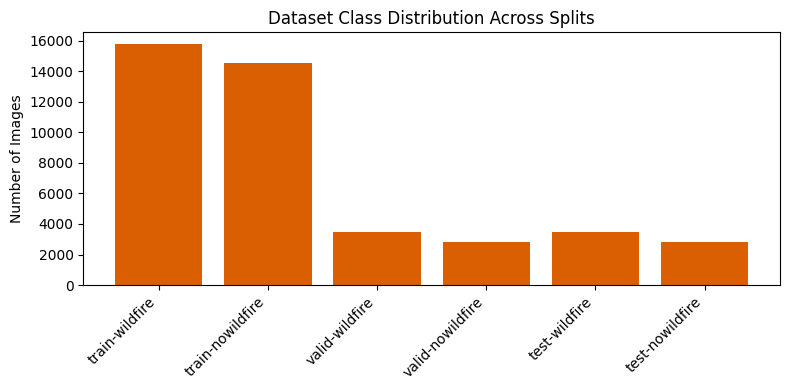

In [6]:
# 5. Visualize Dataset Distribution
import matplotlib.pyplot as plt
from collections import Counter
import os

def get_class_counts(split):
    split_dir = os.path.join(dst, split)
    counts = Counter()
    if not os.path.exists(split_dir):
        return counts
    for cls in os.listdir(split_dir):
        cls_path = os.path.join(split_dir, cls)
        if os.path.isdir(cls_path):
            n = sum(len(files) for _, _, files in os.walk(cls_path))
            counts[cls] += n
    return counts

splits = ["train", "valid", "test"]
bar_labels, bar_heights = [], []

for split in splits:
    counts = get_class_counts(split)
    for cls, n in counts.items():
        bar_labels.append(f"{split}-{cls}")
        bar_heights.append(n)

plt.figure(figsize=(8,4))
plt.bar(bar_labels, bar_heights, color=["#d95f02" if "wildfire" in b else "#1b9e77" for b in bar_labels])
plt.ylabel("Number of Images")
plt.title("Dataset Class Distribution Across Splits")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

os.makedirs(os.path.join(base_dir, "results"), exist_ok=True)
plt.savefig(os.path.join(base_dir, "results", "class_distribution.png"), dpi=300)
plt.show()


In [12]:
# 6. Define Preprocessing & Augmentation Pipelines
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

# Define image transformations
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

valid_test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Create datasets
train_dataset = datasets.ImageFolder(root=os.path.join(dst, "train"), transform=train_transform)
valid_dataset = datasets.ImageFolder(root=os.path.join(dst, "valid"), transform=valid_test_transform)
test_dataset  = datasets.ImageFolder(root=os.path.join(dst, "test"),  transform=valid_test_transform)

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

# Summary
class_names = train_dataset.classes
print("Classes:", class_names)
print("Train size:", len(train_dataset))
print("Valid size:", len(valid_dataset))
print("Test size:", len(test_dataset))


Classes: ['nowildfire', 'wildfire']
Train size: 30250
Valid size: 6300
Test size: 6300


In [13]:
# 7. Compute Class Weights (to handle imbalance)
import numpy as np

labels = np.array([y for _, y in train_dataset.samples])
class_sample_counts = np.bincount(labels).astype(int)

print("Train class counts:", {cls: int(n) for cls, n in zip(class_names, class_sample_counts)})

# Compute normalized inverse-frequency weights
class_weights = 1.0 / (class_sample_counts + 1e-6)
class_weights = class_weights / class_weights.sum() * len(class_weights)
class_weights = class_weights.astype(float)

print("Class weights:", {cls: round(float(w), 4) for cls, w in zip(class_names, class_weights)})

# Save weights for training
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)


Train class counts: {'nowildfire': 14500, 'wildfire': 15750}
Class weights: {'nowildfire': 1.0413, 'wildfire': 0.9587}


In [14]:
# 8. Baseline CNN Model
import torch
import torch.nn as nn
import torch.nn.functional as F

class WildfireCNN(nn.Module):
    def __init__(self, num_classes=2):
        super(WildfireCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool2d(2, 2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.fc1   = nn.Linear(128 * 8 * 8, 256)
        self.fc2   = nn.Linear(256, num_classes)
        self.dropout = nn.Dropout(0.4)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = self.pool(F.relu(self.conv4(x)))
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

model = WildfireCNN(num_classes=2)
print(model)


WildfireCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=8192, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=2, bias=True)
  (dropout): Dropout(p=0.4, inplace=False)
)


In [15]:
# 9. Define Loss, Optimizer, and Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor.to(device))
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [16]:
# 10. Training Loop (5–10 Epochs)
from tqdm import tqdm
import matplotlib.pyplot as plt

num_epochs = 10
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0, 0, 0
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader.dataset)
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # ----- Validation -----
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss /= len(valid_loader.dataset)
    val_acc = val_correct / val_total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs}: "
          f"Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}, "
          f"Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}")


Epoch 1/10: 100%|██████████| 946/946 [02:06<00:00,  7.50it/s]


Epoch 1/10: Train Loss=0.2404, Val Loss=0.1574, Train Acc=0.9073, Val Acc=0.9463


Epoch 2/10: 100%|██████████| 946/946 [02:06<00:00,  7.45it/s]


Epoch 2/10: Train Loss=0.1899, Val Loss=0.1394, Train Acc=0.9288, Val Acc=0.9435


Epoch 3/10: 100%|██████████| 946/946 [02:05<00:00,  7.51it/s]


...

Epoch 8/10: Train Loss=0.1340, Val Loss=0.1222, Train Acc=0.9517, Val Acc=0.9549


Epoch 9/10: 100%|██████████| 946/946 [02:05<00:00,  7.56it/s]


Epoch 9/10: Train Loss=0.1239, Val Loss=0.1002, Train Acc=0.9553, Val Acc=0.9670


Epoch 10/10: 100%|██████████| 946/946 [02:04<00:00,  7.59it/s]


Epoch 10/10: Train Loss=0.1232, Val Loss=0.0941, Train Acc=0.9556, Val Acc=0.9659


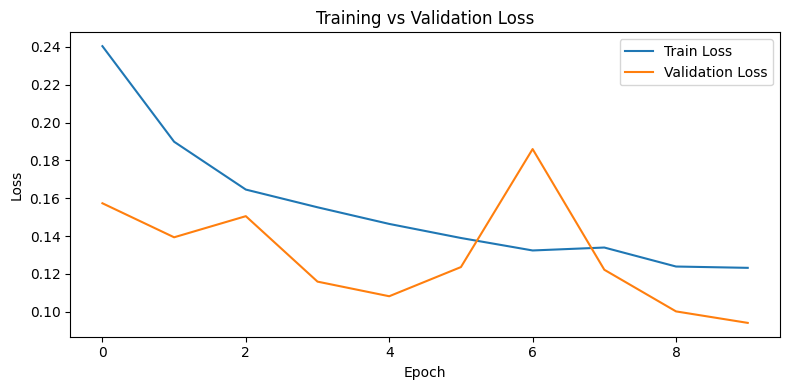

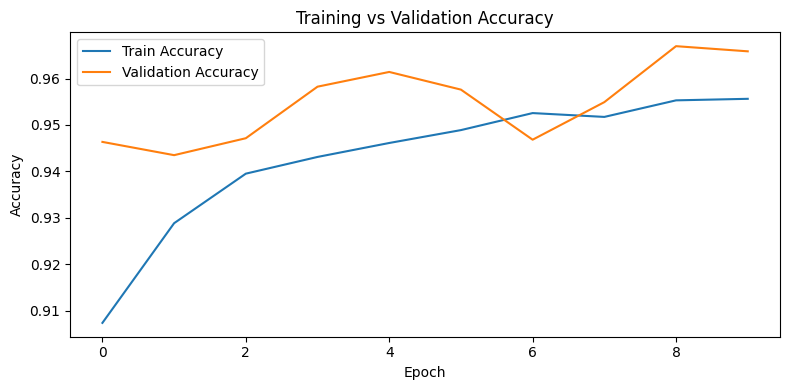

In [20]:
#11. Plot Loss and Accuracy Curves
plt.figure(figsize=(8,4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.tight_layout()
plt.savefig("wildfire-prediction/results/loss_curve.png", dpi=300)
plt.show()

plt.figure(figsize=(8,4))
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig("wildfire-prediction/results/accuracy_curve.png", dpi=300)
plt.show()


In [23]:
#12. Save model
import os
save_path = "wildfire-prediction/models/model_cnn.pt"
os.makedirs(os.path.dirname(save_path), exist_ok=True)

torch.save(model.state_dict(), save_path)

In [25]:
#13. Reload the Model & prepare the Test Loader
import torch
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Recreate model and load saved weights
model = WildfireCNN(num_classes=2).to(device)
model.load_state_dict(torch.load("wildfire-prediction/models/model_cnn.pt", map_location=device))
model.eval()

# Data loader for test set
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [26]:
#14. make predictions and collect output
import numpy as np
from tqdm import tqdm

all_labels, all_preds, all_probs = [], [], []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Evaluating on Test Set"):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())  # probability of "wildfire"


Evaluating on Test Set: 100%|██████████| 197/197 [00:18<00:00, 10.53it/s]


Classification Report:
              precision    recall  f1-score   support

  nowildfire     0.9887    0.9596    0.9739      2820
    wildfire     0.9631    0.9897    0.9762      3004

    accuracy                         0.9751      5824
   macro avg     0.9759    0.9746    0.9751      5824
weighted avg     0.9755    0.9751    0.9751      5824



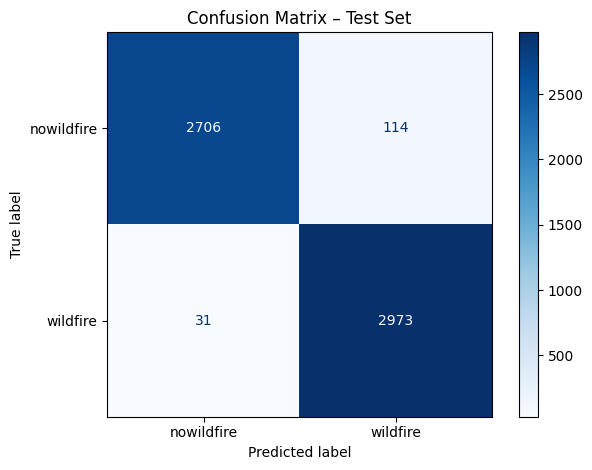

In [29]:
#15. Classification Report & Confusion Matrix
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix – Test Set")
plt.tight_layout()
plt.savefig("wildfire-prediction/results/confusion_matrix.png", dpi=300)
plt.show()


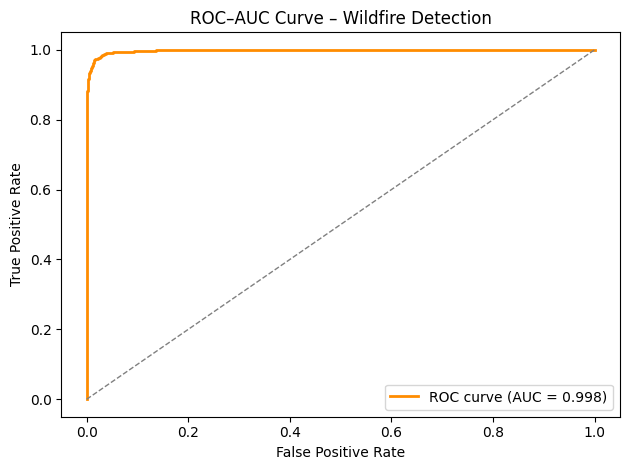

ROC–AUC Score: 0.998


In [31]:
#16. ROC–AUC Curve
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC–AUC Curve – Wildfire Detection")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("wildfire-prediction/results/roc_auc_curve.png", dpi=300)
plt.show()

print(f"ROC–AUC Score: {roc_auc:.3f}")
